In [12]:
#1. IntroductionThis is a comprehensive Machine Learning project designed to analyze and predict student academic outcomes.
#By moving beyond simple grade tracking, the system evaluates a wide range of social, environmental, and behavioral factors to forecast final
#academic performance ($G3$) with high precision.
#2. Key Objectives
#Predictive Modeling: Building an AI model capable of predicting a student's final grade based on initial input data.
#Feature Influence Analysis: Identifying the most critical factors—such as study time, parental education, or previous period grades—that determine academic success.
#Decision Support: Providing educators and institutions with data-driven insights to enable early intervention for at-risk students.
#Technical Stack
#Programming Language: Python.
#Primary Algorithm: Random Forest Regressor (selected for its superior ability to handle non-linear relationships and complex social data).
#Core Libraries:
#Pandas: For advanced data manipulation and cleaning.
#Scikit-learn: For model building, training, and evaluation.
#Matplotlib / Seaborn: For data visualization and result representation.
#Project Deliverables
#High-Accuracy Model: A regression model that provides numerical grade predictions with a minimized Mean Squared Error (MSE).
#Feature Importance Map: A technical report ranking the variables that most impact student performance, offering a "why" behin#d the results.
#Processed Dataset: A refined version of the data where categorical variables (like address and family status) are encoded for statistical analysis.


## 3. Data Loading and Initial Inspection

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('/content/student_data.csv')

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 4. Data Preprocessing

In [14]:
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(exclude=['object']).columns

print(f"Categorical Features: {list(categorical_features)}")
print(f"Numerical Features: {list(numerical_features)}")

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("\nFirst 5 rows of the dataset after one-hot encoding:")
display(df_encoded.head())

Categorical Features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical Features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows of the dataset after one-hot encoding:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


## 5. Feature and Target Separation

In [15]:
# Define features (X) and target (y)
X = df_encoded.drop('G3', axis=1) # G3 is the final grade target variable
y = df_encoded['G3']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (395, 41)
Shape of target (y): (395,)


## 6. Model Training

In [16]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Test set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
print("\nTraining the Random Forest Regressor model...")
model.fit(X_train, y_train)
print("Model training complete.")

Training set shape (X_train, y_train): (316, 41), (316,)
Test set shape (X_test, y_test): (79, 41), (79,)

Training the Random Forest Regressor model...
Model training complete.


## 7. Model Evaluation

Mean Squared Error (MSE): 3.80


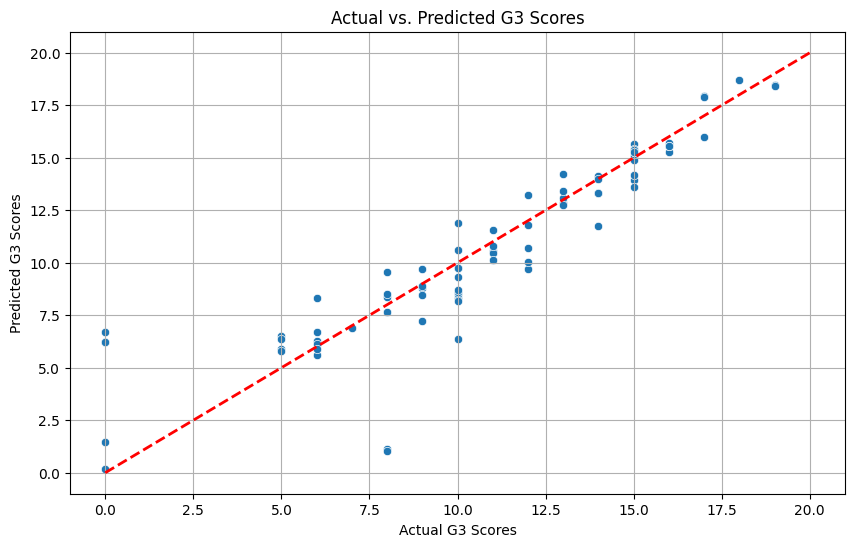

In [17]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Visualize actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual G3 Scores")
plt.ylabel("Predicted G3 Scores")
plt.title("Actual vs. Predicted G3 Scores")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.show()

Top 15 Most Important Features:


,feature,importance
14,G2,0.793254
12,absences,0.110093
28,reason_home,0.021086
0,age,0.010433
13,G1,0.005979
6,famrel,0.005260
8,goout,0.004840
11,health,0.004190
36,activities_yes,0.003933
4,studytime,0.003697


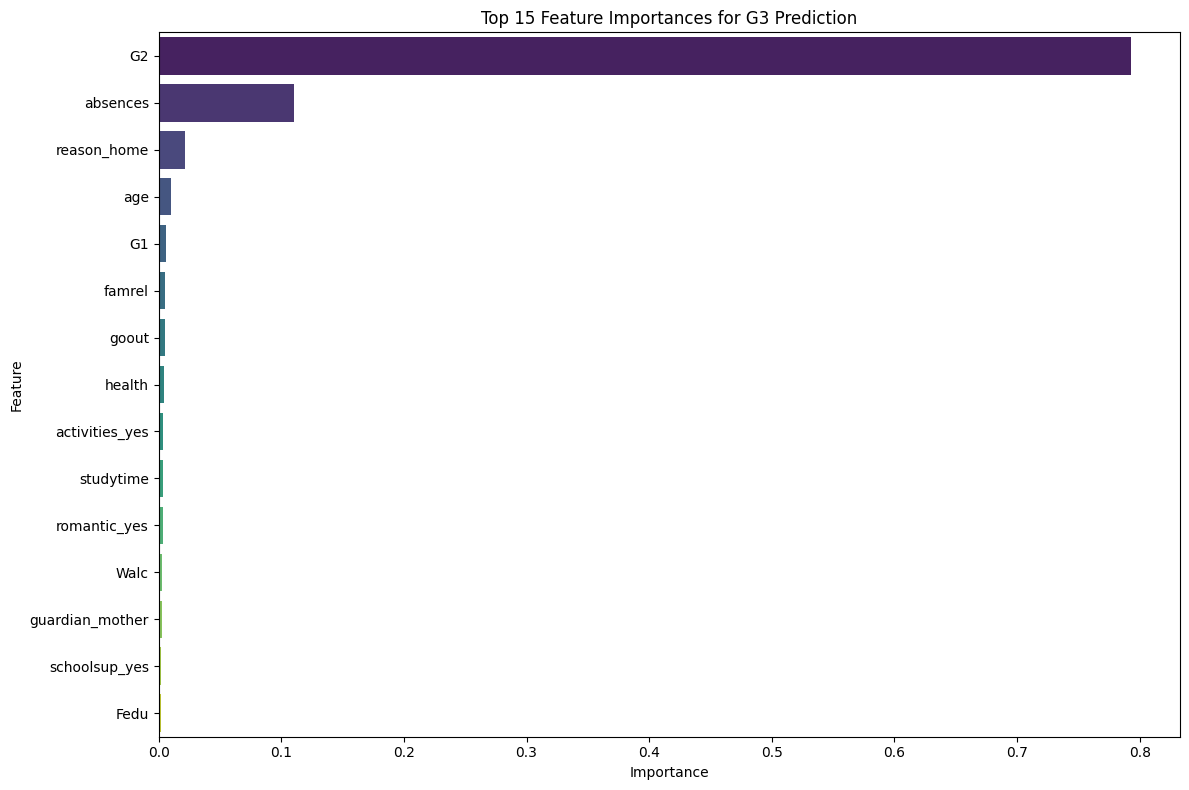

In [18]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a pandas Series for better visualization
feature_names = X.columns
importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

# Sort features by importance in descending order
importances_df = importances_df.sort_values(by='importance', ascending=False)

# Display the top 15 most important features
print("Top 15 Most Important Features:")
display(importances_df.head(15))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', hue='feature', data=importances_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 Feature Importances for G3 Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

To understand the relationships between all variables, including the encoded categorical features and the target variable (`G3`), a correlation heatmap is generated. This visualization helps identify both positive and negative correlations within the dataset.

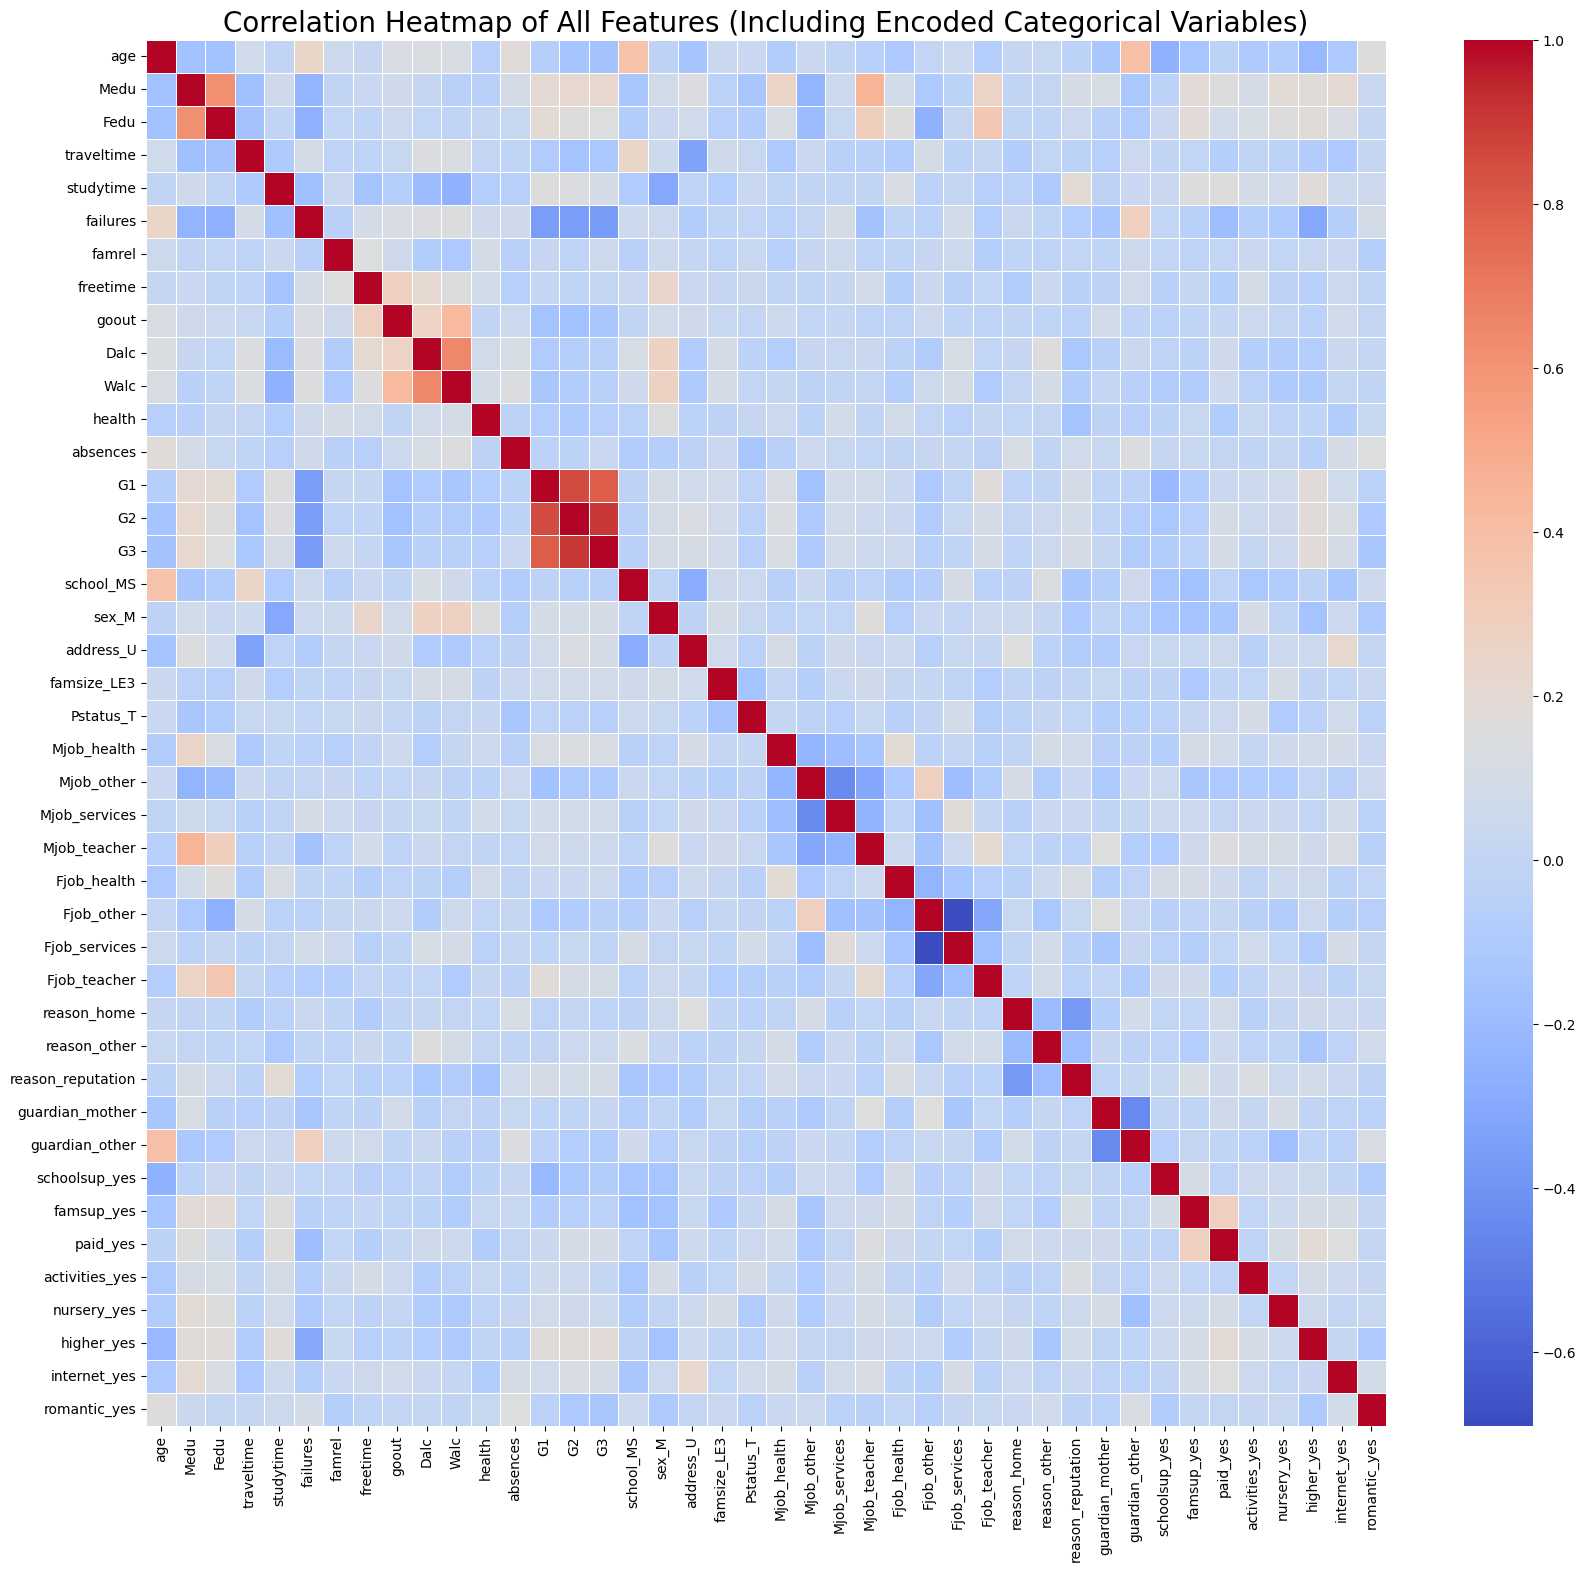


Correlations with G3 (Final Grade):


,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
higher_yes,0.182465
Fedu,0.152457
Mjob_health,0.116158
address_U,0.105756
sex_M,0.103456
paid_yes,0.101996


In [19]:
# Calculate the correlation matrix for the encoded dataframe
correlation_matrix = df_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of All Features (Including Encoded Categorical Variables)', fontsize=20)
plt.show()

# Optional: Display correlations with G3 (final grade) specifically
print("\nCorrelations with G3 (Final Grade):")
display(correlation_matrix['G3'].sort_values(ascending=False).head(20))

## 10. Focused Correlation Analysis with G3

To better understand the factors most directly influencing the final grade (`G3`), we will create a dedicated heatmap showing only the correlations with `G3`. Additionally, a bar plot will highlight the top 10 features (both positively and negatively) that correlate most strongly with `G3`.


Top 10 features most correlated with G3 (absolute value):


,G3
G2,0.904868
G1,0.801468
Medu,0.217147
higher_yes,0.182465
Fedu,0.152457
traveltime,-0.117142
romantic_yes,-0.129970
goout,-0.132791
age,-0.161579
failures,-0.360415


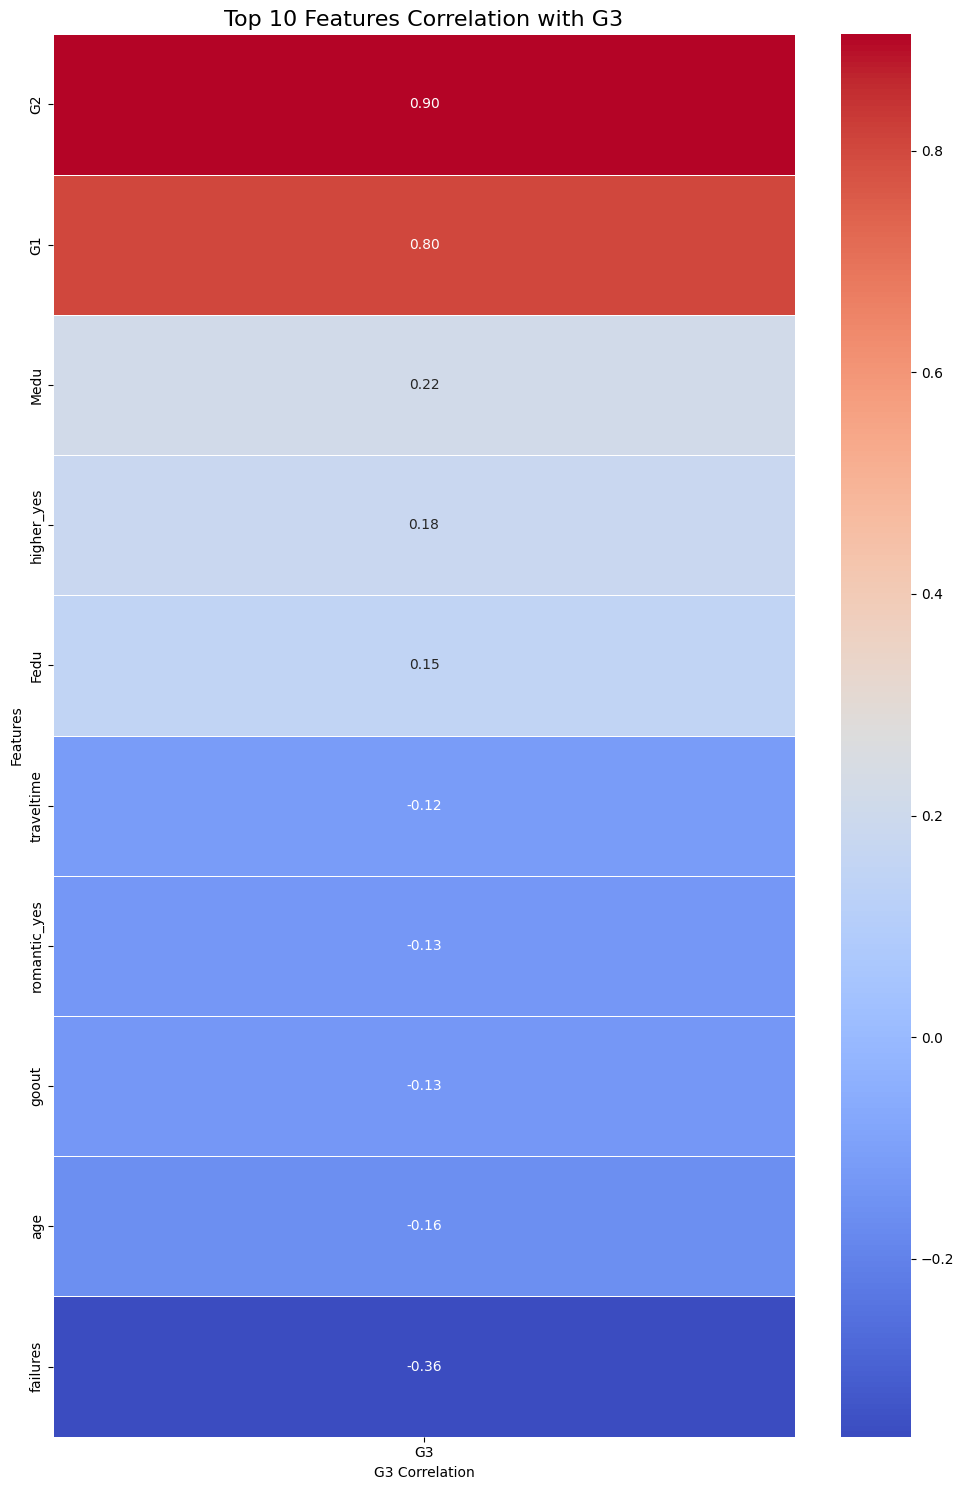

/tmp/ipykernel_33665/1435390350.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_g3_values.values, y=top_10_g3_values.index, palette='viridis')


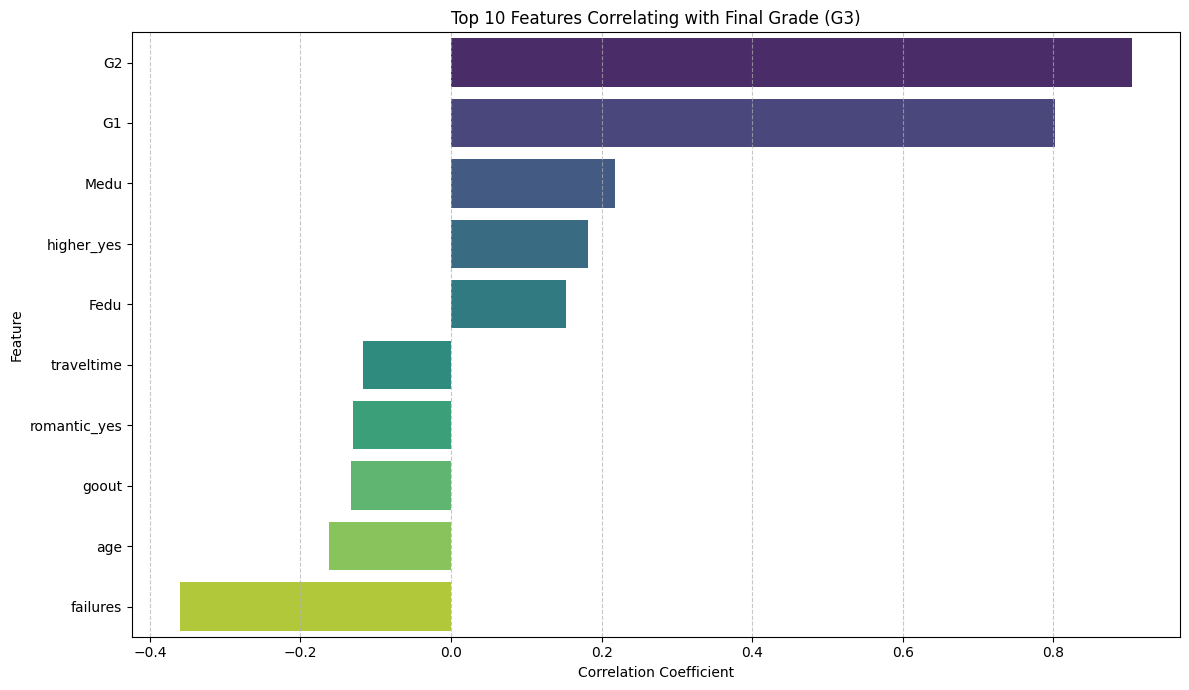

In [20]:
# Calculate correlations with G3
g3_correlations = correlation_matrix['G3'].drop('G3') # Drop self-correlation

# Sort correlations for G3
sorted_g3_correlations = g3_correlations.abs().sort_values(ascending=False)

# Get the top 10 most correlated features (absolute value)
top_10_features_g3 = sorted_g3_correlations.head(10).index.tolist()

# Extract the actual correlation values for these top 10 features
top_10_g3_values = g3_correlations[top_10_features_g3].sort_values(ascending=False)

print("\nTop 10 features most correlated with G3 (absolute value):")
display(top_10_g3_values.to_frame())

# Visualize correlations with G3 as a heatmap
plt.figure(figsize=(10, 15))
sns.heatmap(top_10_g3_values.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)
plt.title('Top 10 Features Correlation with G3', fontsize=16)
plt.xlabel('G3 Correlation')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Create a bar plot for the top 10 features correlating with G3
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_g3_values.values, y=top_10_g3_values.index, palette='viridis')
plt.title('Top 10 Features Correlating with Final Grade (G3)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()